In [17]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.axes import Axes

from afolu.defs.assets.constants import LABEL_LIST

In [18]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [25]:
ZONE = "MEX+Monterrey"

In [26]:
import geopandas as gpd

bbox = gpd.read_file(out_path / "small" / "bbox" / "shapely" / f"{ZONE}.gpkg")
bbox.to_crs("ESRI:102033").area.item() / 1e4

328303.66453376535

# Área

Cargamos las DataFrame de área:

In [27]:
def load_area_df(fpath: os.PathLike) -> pd.DataFrame:
    return (
        pd.read_csv(fpath)
        .set_index("label")
        .transpose()
        .reset_index(names="index")
        .assign(index=lambda df: df["index"].astype(int) + 2000)
        .rename(columns={"index": "year"})
        .query("year <= 2035")
        .set_index("year")
        .divide(100)
    )

In [28]:
df_normal = load_area_df(
    out_path / "small" / "forecast" / "area" / "normal" / f"{ZONE}.csv",
)
df_fast = load_area_df(
    out_path / "small" / "forecast" / "area" / "fast" / f"{ZONE}.csv",
)
df_slow = load_area_df(
    out_path / "small" / "forecast" / "area" / "slow" / f"{ZONE}.csv",
)

In [29]:
df_normal_frac = df_normal.div(df_normal.sum(axis=1), axis=0)
df_fast_frac = df_fast.div(df_fast.sum(axis=1), axis=0)
df_slow_frac = df_slow.div(df_slow.sum(axis=1), axis=0)

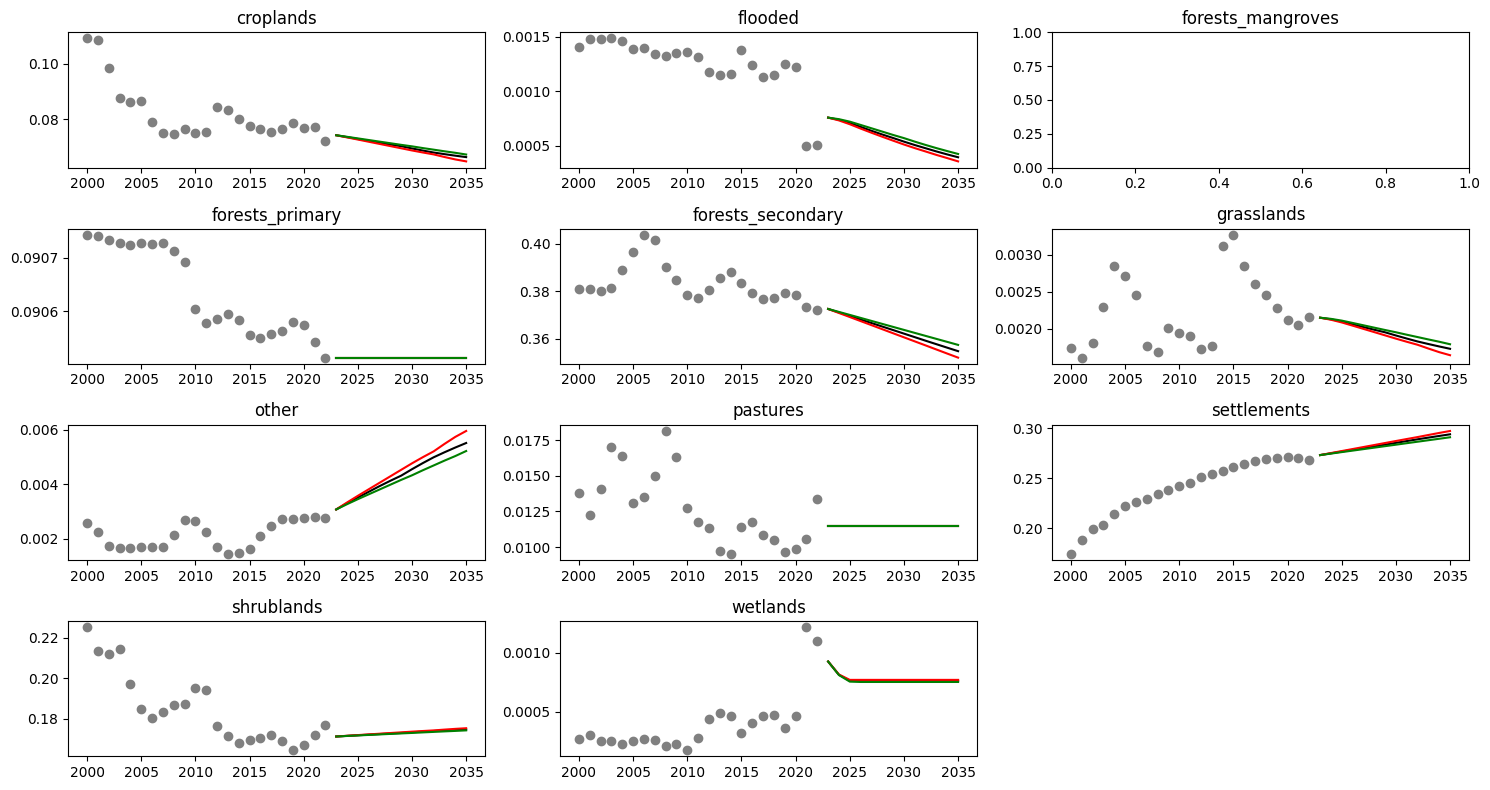

In [30]:
fig, axes = plt.subplots(4, 3, figsize=(15, 8))

for label, ax in zip(LABEL_LIST, axes.flatten(), strict=False):
    ax.set_title(label)
    if label == "forests_mangroves":
        continue
    df_normal_frac.loc[:2022, label].plot(
        ax=ax,
        color="gray",
        marker="o",
        linestyle="None",
    )
    df_normal_frac.loc[2023:, label].plot(ax=ax, color="k")
    df_fast_frac.loc[2023:, label].plot(ax=ax, c="r")
    df_slow_frac.loc[2023:, label].plot(ax=ax, c="green")
    ax.set_xlabel("")

axes[-1, -1].axis("off")

fig.tight_layout()

Graficamos los escenarios

In [31]:
def plot_scenarios(
    series_fast: pd.Series,
    series_normal: pd.Series,
    series_slow: pd.Series,
    *,
    ax: Axes,
    scatter: bool = False,
    legend: bool = True,
    plot_normal: bool = True,
    plot_slow: bool = True,
    plot_fast: bool = True,
) -> None:
    historical = series_fast.loc[:2022]

    fast = series_fast.loc[2023:]
    normal = series_normal.loc[2023:]
    slow = series_slow.loc[2023:]

    if scatter:
        historical.plot(
            ax=ax,
            label="Histórico",
            color="gray",
            marker="o",
            linestyle="None",
        )
    else:
        historical.plot(ax=ax, label="Histórico", color="gray")

    if plot_fast:
        fast.plot(ax=ax, label="Acelerado", color="red")

    if plot_normal:
        normal.plot(ax=ax, label="Normal", color="black")

    if plot_slow:
        slow.plot(ax=ax, label="Desacelerado", color="green")

    if legend:
        ax.legend()

## Bosques

Text(0.5, 1.0, 'Bosques')

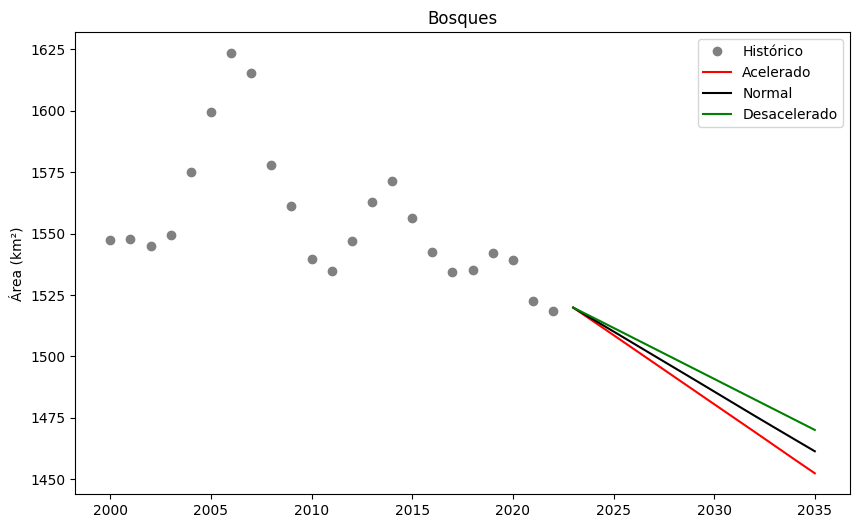

In [32]:
forest_fast = df_fast["forests_primary"] + df_fast["forests_secondary"]
forest_normal = df_normal["forests_primary"] + df_normal["forests_secondary"]
forest_slow = df_slow["forests_primary"] + df_slow["forests_secondary"]

fig, ax = plt.subplots(figsize=(10, 6))
plot_scenarios(forest_fast, forest_normal, forest_slow, ax=ax, scatter=True)

ax.set_xlabel("")
ax.set_ylabel("Área (km²)")
ax.set_title("Bosques")

## Asentamientos

Text(0.5, 1.0, 'Asentamientos')

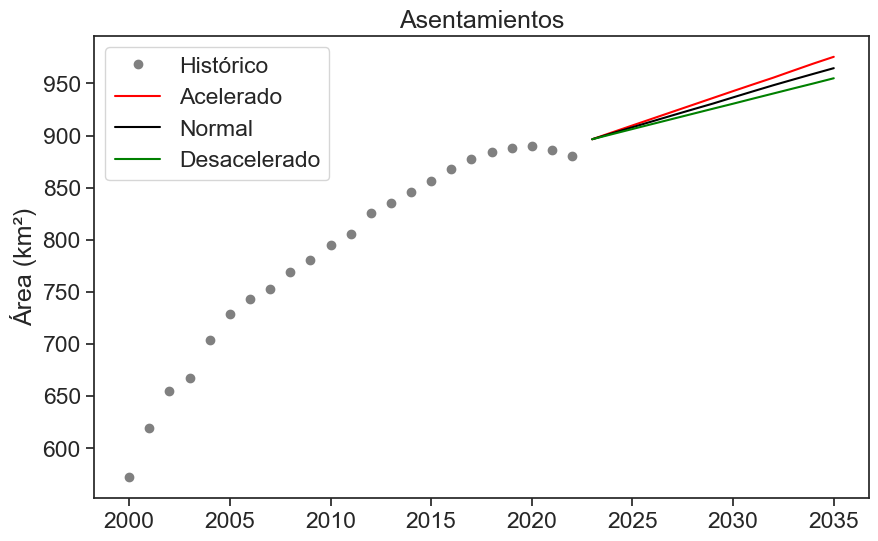

In [33]:
sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(10, 6))
plot_scenarios(
    df_fast["settlements"],
    df_normal["settlements"],
    df_slow["settlements"],
    ax=ax,
    scatter=True,
    legend=True,
)

ax.set_xlabel("")
ax.set_ylabel("Área (km²)")
ax.set_title("Asentamientos")

# Diferencia de captura entre escenarios

In [34]:
def load_emission_df(fpath: os.PathLike) -> pd.DataFrame:
    return (
        pd.read_csv(fpath)
        .assign(time_period=lambda df: df["time_period"].astype(int) + 2000)
        .rename(columns={"time_period": "year"})
        .query("year <= 2035")
        .set_index("year")
    )


df_emissions_fast = load_emission_df(
    out_path / "small" / "forecast" / "emissions" / "fast" / f"{ZONE}.csv",
)
df_emissions_normal = load_emission_df(
    out_path / "small" / "forecast" / "emissions" / "normal" / f"{ZONE}.csv",
)
df_emissions_slow = load_emission_df(
    out_path / "small" / "forecast" / "emissions" / "slow" / f"{ZONE}.csv",
)

In [35]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst",
]

In [36]:
sequestration_fast = (
    df_emissions_fast[sequestration_columns].sum(axis=1).abs().mul(1000)
)
sequestration_normal = (
    df_emissions_normal[sequestration_columns].sum(axis=1).abs().mul(1000)
)
sequestration_slow = (
    df_emissions_slow[sequestration_columns].sum(axis=1).abs().mul(1000)
)

<Axes: xlabel='year'>

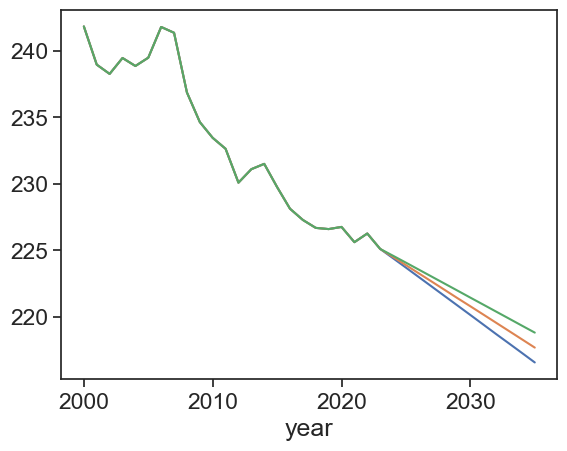

In [37]:
sequestration_fast.plot()
sequestration_normal.plot()
sequestration_slow.plot()

Text(0, 0.5, 'Carbono capturado (miles de toneladas)')

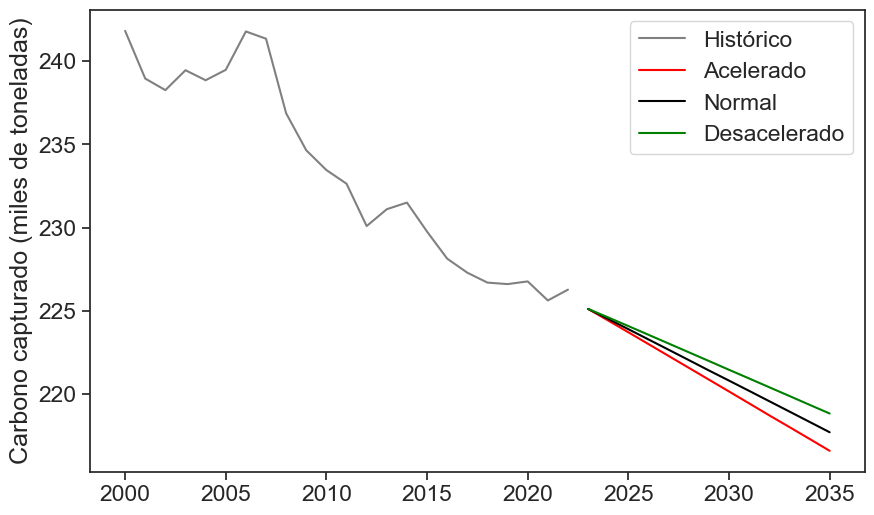

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_scenarios(sequestration_fast, sequestration_normal, sequestration_slow, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Carbono capturado (miles de toneladas)")

In [39]:
df_emissions_fast[
    [c for c in df_emissions_fast.columns if "emission_co2e" in c and "lndu" in c]
]

,emission_co2e_co2_lndu_conversion_away_croplands,emission_co2e_co2_lndu_conversion_away_flooded,emission_co2e_co2_lndu_conversion_away_forests_mangroves,emission_co2e_co2_lndu_conversion_away_forests_primary,emission_co2e_co2_lndu_conversion_away_forests_secondary,emission_co2e_co2_lndu_conversion_away_grasslands,emission_co2e_co2_lndu_conversion_away_other,emission_co2e_co2_lndu_conversion_away_pastures,emission_co2e_co2_lndu_conversion_away_settlements,emission_co2e_co2_lndu_conversion_away_shrublands,...,emission_co2e_co2_lndu_conversion_wetlands_to_forests_mangroves,emission_co2e_co2_lndu_conversion_wetlands_to_forests_primary,emission_co2e_co2_lndu_conversion_wetlands_to_forests_secondary,emission_co2e_co2_lndu_conversion_wetlands_to_grasslands,emission_co2e_co2_lndu_conversion_wetlands_to_other,emission_co2e_co2_lndu_conversion_wetlands_to_pastures,emission_co2e_co2_lndu_conversion_wetlands_to_settlements,emission_co2e_co2_lndu_conversion_wetlands_to_shrublands,emission_co2e_co2_lndu_conversion_wetlands_to_wetlands,emission_co2e_subsector_total_lndu
year,,,,,,,,,,,,,,,,,,,,,
2000,0.0,0.0,0.0,0.000478,0.305150,0.000275,0.0,0.001856,0.0,0.179005,...,0.0,0.0,0.0,0.0,4.098868e-07,0.0,0.000004,0.0,0.0,0.433062
2001,0.0,0.0,0.0,0.000666,0.315514,0.000169,0.0,0.000799,0.0,0.142466,...,0.0,0.0,0.0,0.0,1.636044e-06,0.0,0.000012,0.0,0.0,0.408814
2002,0.0,0.0,0.0,0.000869,0.286329,0.000078,0.0,0.000627,0.0,0.108403,...,0.0,0.0,0.0,0.0,4.081790e-07,0.0,0.000005,0.0,0.0,0.345784
2003,0.0,0.0,0.0,0.000742,0.225340,0.000109,0.0,0.001301,0.0,0.170909,...,0.0,0.0,0.0,0.0,9.963410e-07,0.0,0.000014,0.0,0.0,0.347271
2004,0.0,0.0,0.0,0.000479,0.246233,0.000201,0.0,0.001644,0.0,0.126445,...,0.0,0.0,0.0,0.0,4.027013e-07,0.0,0.000005,0.0,0.0,0.327990
2005,0.0,0.0,0.0,0.000624,0.254849,0.000160,0.0,0.000717,0.0,0.085260,...,0.0,0.0,0.0,0.0,6.084239e-07,0.0,0.000011,0.0,0.0,0.297503
2006,0.0,0.0,0.0,0.000592,0.343597,0.000519,0.0,0.000917,0.0,0.097364,...,0.0,0.0,0.0,0.0,6.082794e-07,0.0,0.000010,0.0,0.0,0.399979
2007,0.0,0.0,0.0,0.001274,0.525983,0.000212,0.0,0.001050,0.0,0.112817,...,0.0,0.0,0.0,0.0,1.217122e-06,0.0,0.000011,0.0,0.0,0.597648
2008,0.0,0.0,0.0,0.002060,0.384940,0.000107,0.0,0.002626,0.0,0.115192,...,0.0,0.0,0.0,0.0,8.104359e-07,0.0,0.000008,0.0,0.0,0.460392


In [40]:
df_emissions_fast / df_fast

,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,area_agrc_crops_other_woody_perennial,area_agrc_crops_pulses,area_agrc_crops_rice,...,yield_agrc_fruits_tonne,yield_agrc_herbs_and_other_perennial_crops_tonne,yield_agrc_nuts_tonne,yield_agrc_other_annual_tonne,yield_agrc_other_woody_perennial_tonne,yield_agrc_pulses_tonne,yield_agrc_rice_tonne,yield_agrc_sugar_cane_tonne,yield_agrc_tubers_tonne,yield_agrc_vegetables_and_vines_tonne
year,,,,,,,,,,,,,,,,,,,,,
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
(sequestration_slow - sequestration_normal).sum()

np.float64(7.294878176384856)

In [42]:
print(
    f"Si se lograse desacelerar la urbanización y deforestación por un 20%, se capturarían {(sequestration_slow - sequestration_normal).sum():,.0f} mil toneladas de CO₂ más que en el escenario normal.",
)

Si se lograse desacelerar la urbanización y deforestación por un 20%, se capturarían 7 mil toneladas de CO₂ más que en el escenario normal.
